## Download the dataset

In [52]:
# Load the token into this notebook's environment
import os
from google.colab import userdata

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

In [53]:
# Create the Kaggle config folder
!mkdir -p ~/.kaggle

In [54]:
# Save the token into the file Kaggle's client expects
!echo $KAGGLE_API_TOKEN > ~/.kaggle/access_token

In [55]:
# Lock down the file permissions (Kaggle requires this)
!chmod 600 ~/.kaggle/access_token

In [56]:
# Download the data
!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews -p /content/data

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
imdb-dataset-of-50k-movie-reviews.zip: Skipping, found more recently modified local copy (use --force to force download)


In [57]:
# Unzip it
!unzip -oq /content/data/imdb-dataset-of-50k-movie-reviews.zip -d /content/data

In [58]:
# Check it worked
!ls /content/data

'IMDB Dataset.csv'   imdb-dataset-of-50k-movie-reviews.zip


## Dataset exploration

In [59]:
import pandas as pd

In [60]:
imdb_df = pd.read_csv('/content/data/IMDB Dataset.csv')

Let's take a quick look at the `imdb_df`

In [61]:
imdb_df.sample(10)

,review,sentiment
5102,This movie was portrayed in the trailer as a c...,negative
7957,Bridges's drama about a reporter who discovers...,positive
7017,"A good film with--for its time--an intense, sp...",positive
33211,The Man with Bogart's Face sets it self up to ...,negative
44408,"i just wanted to say i liked this movie a lot,...",positive
38144,"Well, it has to be said that Monster Man is a ...",positive
41359,I was very surprised how much I enjoyed this f...,positive
10392,Reporter Kimberly Wells presents the minor sid...,positive
12956,I saw this little magnum opus for the first ti...,negative
37104,Perhaps not my genre but plot was horrible as ...,negative


Let's check the dataset's `shape`

In [62]:
imdb_df.shape

(50000, 2)

Let's check the balance of the dataset

In [63]:
imdb_df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


Okay, our dataset is quite balanced

Let's check the `info` of the dataset

In [64]:
imdb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


It seems we don't have any `NULL` values, let's confirm it

In [65]:
imdb_df.isnull().sum()

,0
review,0
sentiment,0


Confirmed, there are no `NULL` values

Let's check the statistics of the dataset

In [66]:
imdb_df.describe().T

,count,unique,top,freq
review,50000,49582,Loved today's show!!! It was a variety and not...,5
sentiment,50000,2,positive,25000


Let's check the duplicates

In [67]:
imdb_df.duplicated().sum()

np.int64(418)

Okay, we have less than 1% duplicate data, let's drop them

In [68]:
imdb_df = imdb_df.drop_duplicates()

Let's confirm the duplicates removal

In [69]:
imdb_df.duplicated().sum()

np.int64(0)

Let's take a look at the number of characters present in each `review`. This can give us a rough idea about the movie's review.\
Let's plot using `Matplotlib`.

In [70]:
import matplotlib.pyplot as plt

In [71]:
imdb_df['word_count'] = imdb_df['review'].str.len()

Text(0.5, 1.0, 'Review length distribution')

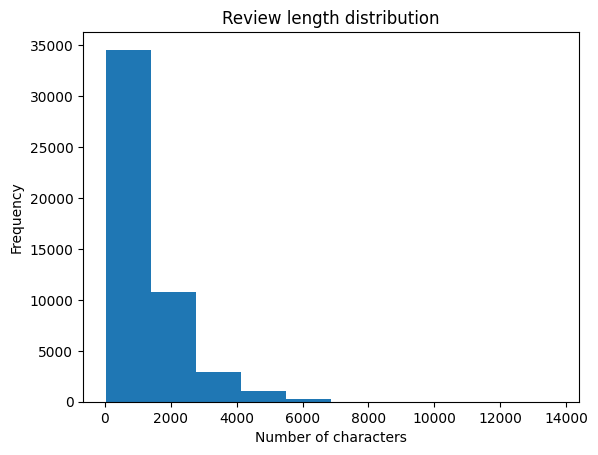

In [72]:
# number of characters in each review
r_length = imdb_df['review'].str.len()

# plot
plt.hist(r_length)
plt.xlabel('Number of characters')
plt.ylabel('Frequency')
plt.title("Review length distribution")

This histogram shows that reviews range from 10 to 14000 characters; but generally it's ranging from 10 to 1000.\
it will help us to decide RNN/FNN padding length later.

## Text cleaning

Let's define `clean_text` function to clean texts

In [73]:
import re

def clean_text(text):
  text = text.lower()                      # converting to lowercase
  text = re.sub(r'<.*?>', '', text)        # strip HTML tags
  text = re.sub(r'[^a-zA-Z\s]', '', text)  # keep only letters + whitespace
  text = re.sub(r'\s+', ' ', text).strip() # collapse extra whitespace, trim ends
  return text


In [74]:
imdb_df['review_cleaned'] = imdb_df['review'].apply(clean_text)

Since we have cleaned review column let's drop the row (messy) review column.

In [75]:
imdb_df = imdb_df.drop('review', axis=1)

## Train-Test Split

In [76]:
from sklearn.model_selection import train_test_split

we have our sentiment values as texts: `positive` and `negative`. let's convert them as numericals,\
otherwise it won't help during our training

In [77]:
imdb_df['sentiment'] = imdb_df['sentiment'].map({'positive': 1, 'negative': 0})

In [78]:
X_train, X_test, y_train, y_test = train_test_split(imdb_df['review_cleaned'],
                                                    imdb_df['sentiment'],
                                                    random_state=42,
                                                    test_size=0.2,
                                                    stratify=imdb_df['sentiment'])

---
---

## Phase A: BoW + Logistic Regression

### Vectorization with `CountVectorizer`

We are going to use `CountVectorizer` from sklearn, which is basically `BoW` under the hood

In [79]:
from sklearn.feature_extraction.text import CountVectorizer

In [80]:
bow_vectorizer = CountVectorizer(max_features=10000, stop_words='english')

* `max_features=10000` caps vocabulary to the 10k most frequent words, keeps dimensionality manageable and avoids overfitting on rare words that appear once or twice

* `stop_words='english'` removes common words like "the," "is," "a" before counting

  Tradeoff: stopwords carry zero sentiment signal individually, so removing them usually helps BoW/TF-IDF by letting meaningful words dominate the count vector

Next, let's transform our `X_train` and `X_test` into vectors, which will help us to train `LogisticRegression`.

In [81]:
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

### Logistic Regression with BoW

In [82]:
from sklearn.linear_model import LogisticRegression

In [83]:
# Classification using Logistic Regression on BoW
clf_bow = LogisticRegression(random_state=42, max_iter=1000)

In [84]:
clf_bow.fit(X_train_bow, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Predictions

In [85]:
preds_bow = clf_bow.predict(X_test_bow)

### Model Evaluation

In [86]:
from sklearn.metrics import classification_report, confusion_matrix

* `classification_report` — gives precision, recall, F1 per class (positive/negative), accuracy_score; more informative than accuracy alone, especially useful once we'll compare against other phases
* `confusion_matrix` — raw counts of true positive/negative vs. predicted; this is what we'll actually pull misclassified examples from next

In [87]:
print(classification_report(y_test, preds_bow))

              precision    recall  f1-score   support

           0       0.87      0.86      0.87      4940
           1       0.87      0.87      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



* **`Precision`**: of everything the model predicted as this class, what fraction was actually correct?\
E.g., for class 1: of all reviews predicted positive, 87% were truly positive.

* **`Recall`**: of everything that actually is this class, what fraction did the model catch?\
E.g., for class 0: of all truly negative reviews, 86% were correctly identified as negative.

* **`F1-score`**: harmonic mean of precision and recall, single number balancing both.

  on a scale of 0 to 1, this class's predictions balance precision and recall at 0.87 — i.e., the model is both fairly precise and has fairly good recall for that class, combined into one number.
  
  in simple terms, the model is doing a solidly good job — about 87 out of 100 times, it's both correctly identifying the class and not missing too many real cases of it. Not perfect, not bad, decently reliable.

* **`Support`**: how many actual samples of that class exist in the test
set\
(4940 negative, 4977 positive — confirms your split kept classes roughly balanced, consistent with stratify).

* **`accuracy`**: 86.7% of all test predictions were correct. Reasonable baseline for BoW + Logistic Regression on this task.

* **`Macro avg`** vs **`weighted avg`**: here they're identical (0.87) because our classes are nearly balanced (4940 vs 4977 support). Macro avg treats both classes equally regardless of size; weighted avg weights by support. When classes are this close in size, they'll always converge — this row isn't telling us much extra here, but it would matter if our classes were imbalanced.

In [88]:
print(confusion_matrix(y_test, preds_bow))

[[4271  669]
 [ 653 4324]]


* `669` — false positives (negative reviews the model thought were positive)
* `653` — false negatives (positive reviews the model thought were negative)

Roughly symmetric errors (669 vs 653): the model isn't systematically biased toward one class,\
it's making similar-magnitude mistakes both directions.

---
---

## Phase B — TF-IDF + Logistic Regression

### Vectorization with `TfidfVectorizer`

In [89]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [90]:
tfidf_vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')

In [96]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

### Logistic Regression with TF-IDF

In [92]:
from sklearn.linear_model import LogisticRegression

In [93]:
clf_tfidf = LogisticRegression(random_state=42, max_iter=1000)

In [97]:
clf_tfidf.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Predictions

In [100]:
preds_tfidf = clf_tfidf.predict(X_test_tfidf)

### Model evaluation

In [98]:
from sklearn.metrics import classification_report, confusion_matrix

In [102]:
print(classification_report(y_test, preds_tfidf))

              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4940
           1       0.88      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



**`TF-IDF`** wins across every single metric, roughly +2 points on accuracy and F1, consistent improvement in both classes. That's a genuine, meaningful gap, not noise.

## Predictions on real dataset using both models

In [103]:
new_reviews = [
    "This movie was absolutely fantastic, the acting was superb and I loved every minute of it.",
    "This movie was not bad at all, I quite enjoyed it.",              # negation
    "I guess it was okay, nothing special, wouldn't watch it again.",  # mild/ambiguous
    "Great acting, terrible plot, awful pacing.",                      # mixed sentiment
    "What a waste of time, I regret watching this garbage."
]

In [104]:
# clean using the same function: clean_text
cleaned_reviews = [clean_text(review) for review in new_reviews]

In [105]:
# vectorize using the already-fitted vectorizers
new_bow = bow_vectorizer.transform(cleaned_reviews)
new_tfidf = tfidf_vectorizer.transform(cleaned_reviews)

In [106]:
# predict with both classifiers
pred_bow = clf_bow.predict(new_bow)
pred_tfidf = clf_tfidf.predict(new_tfidf)

In [109]:
print('BoW:',pred_bow)
print('TF-IDF:',pred_tfidf)

BoW: [1 1 0 0 0]
TF-IDF: [1 1 0 0 0]


Both models correctly classified 4 out of 5 hand-written reviews, including a negation case ("not bad at all, I quite enjoyed it") that was expected to fail — it didn't, likely because supporting words ("enjoyed," "quite") in the same sentence carried enough signal to outweigh "bad" alone, even without the model understanding grammatical negation.

The one genuinely revealing result was the mixed-sentiment review ("Great acting, terrible plot, awful pacing"), which both models called Negative. This exposes the actual limitation of BoW/TF-IDF clearly: with two negative-toned words ("terrible," "awful") against one positive ("great"), the models effectively vote by word count/weight rather than parsing structure or clause-level meaning. Neither can represent "positive on X, negative on Y" — they collapse everything into a single aggregate sentiment score per document.

**Conclusion:** on simple, single-sentiment reviews, sparse representations perform reliably. Their real weakness shows on reviews with mixed or conflicting sentiment across clauses, not necessarily on negation (which this small sample didn't break, though a larger/more adversarial test set likely would). This mixed-sentiment failure mode is a distinct limitation from negation, and it's one that TF-IDF's weighting scheme doesn't address either — since TF-IDF only reweights word importance, it doesn't add any structural understanding.